# Cohort-vs-cohort DEG comparison

Welch t-test per gene on normative Z-scores between two disease cohorts (not vs HC), BH-FDR corrected within model-route genes (pool-route/rare genes excluded from the FDR-controlled table -- see `pipeline/cohort_stats.py` for the rationale). Comparisons:

- CAD_HF- vs CAD_HF+
- Pancreatitis vs Pancreatic Cancer
- ICI-treated Cancer vs ICI-m

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd

import config
from pipeline import data_prep, scoring, cohort_compare, plots

In [2]:
dd = data_prep.load_disease_filtered()
route = scoring.gene_stage(dd.gene_names)
print(f'{dd.Z_dis.shape[0]} samples, {len(np.unique(dd.dis_pheno))} phenotypes')

854 samples, 20 phenotypes


## DEG tables
Cached to `Cohort_Compare/deg_*.csv`; re-running loads from cache.

`min_hc_dev=0.3`: independent-filtering (Bourgon et al. 2010 PNAS) -- genes whose |mean deviation from HC| doesn't exceed 0.3 in EITHER cohort are excluded from the BH family before re-correcting the rest. Valid because this filter is computed from each cohort's own one-sample vs-HC deviation, independent of the two-cohort p-value under the null. Confirmed empirically to recover real (modest) power without inflating FDR -- see `cohort_compare.run_comparison` docstring.

In [3]:
results = cohort_compare.run_all(dd, route=route, min_hc_dev=0.3)
for name, df in results.items():
    n_sig = (df['padj'] < 0.05).sum()
    print(f'{name:30s}  n_genes={len(df):6d}  n_sig(padj<0.05)={n_sig:5d}')

CAD_HF+_vs_CAD_HF-              n_genes= 20090  n_sig(padj<0.05)= 1327
Pancreatitis_vs_PDAC            n_genes= 20090  n_sig(padj<0.05)=   11
ICI_Cancer_vs_ICIm              n_genes= 20090  n_sig(padj<0.05)=   25


## Volcano plots
x = mean Z difference between cohorts (standardized-deviation scale, not log2FC). Pool-route genes excluded (not independent per-gene hypotheses).

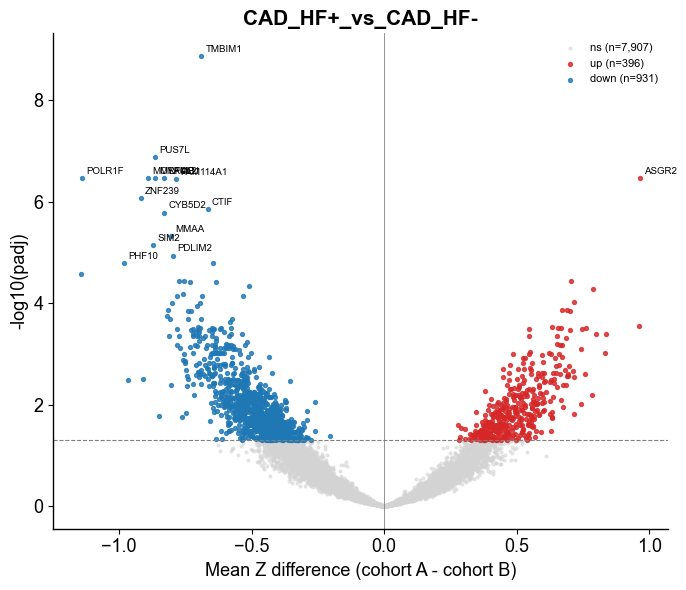

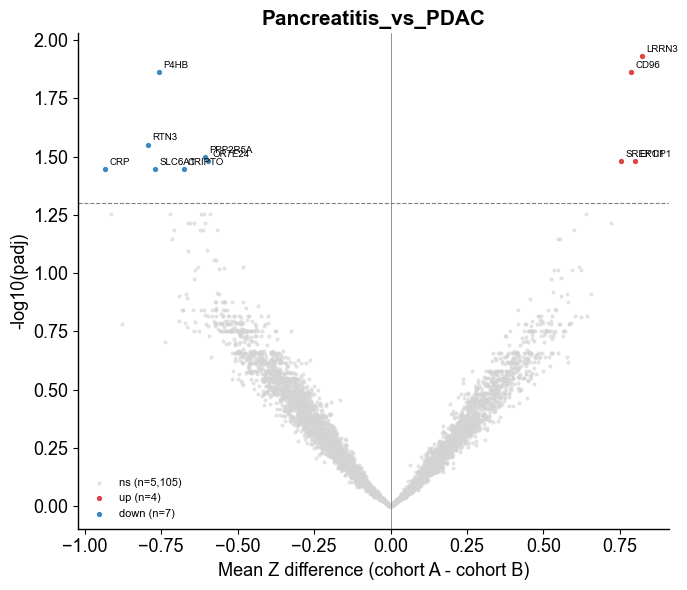

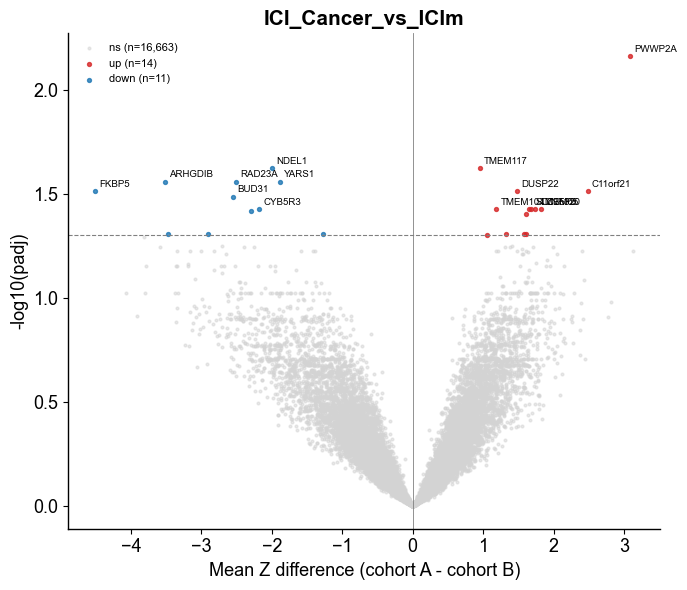

In [4]:
for name, df in results.items():
    plots.plot_volcano(df, name)

## GSEA (prerank on the Welch t-statistic, model-route only)
Cached to `Cohort_Compare/GSEA/{name}/gsea_result_{name}.csv`.

In [5]:
gsea_results = {name: cohort_compare.run_gsea(df, name) for name, df in results.items()}
for name, g in gsea_results.items():
    print(f'{name:30s}  n_sig_terms={len(g)}')

CAD_HF+_vs_CAD_HF-              n_sig_terms=6
Pancreatitis_vs_PDAC            n_sig_terms=385
ICI_Cancer_vs_ICIm              n_sig_terms=1882


## Classification (HC vs the two phenotypes)
Held for later -- needs more thought on setup (deferred per discussion).